In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.miscmodels.ordinal_model import OrderedModel
import statsmodels.formula.api as smf
import re
import seaborn as sns

ANES_YEAR_MIN = 1972 # Lower limit of years to consider for ANES-based model

anes_full = pd.read_csv('raw_data/anes_timeseries_cdf_csv_20260205/anes_timeseries_cdf_csv_20260205.csv')
anes_full = anes_full.rename(columns={
    "VCF0803": "voter_ideo", #Ideological self-placement scale
    "VCF9096": "gop_ideo", #Respondent rating of gop candidate on ideology scale
    "VCF9088": "dem_ideo", #Respondentt rating of dem candidate on ideology scale
    "VCF0830": "voter_resent", #Government aid to blacks question, selected due to time continuity from 1972-2024
    "VCF9092": "gop_resent", #Respondent rating of gop candidate on gov't aid to blacks
    "VCF9084": "dem_resent", #Respondent rating of dem candidate on gov't aid to blacks
    "VCF0901a": "state_fips",
    "VCF0004": "year",
    "VCF0704a": "vote_pres"})
anes_full['state_fips'] = pd.to_numeric(anes_full['state_fips'], errors='coerce').astype('Int64')

# Merge with state postal codes (for interpretability) and region codes
state_codes = pd.read_csv('raw_data/state_fips.csv')
anes_full = pd.merge(anes_full, state_codes, on='state_fips', how='left')
regions = pd.read_csv('raw_data/us_regions_divisions.csv')
regions = regions.rename(columns = {'State': 'state_name', 'State Code': 'state', 'Region': 'census_region', 'Division': 'division'})
anes_full = pd.merge(anes_full, regions[['state','census_region','division']], on = 'state', how = 'left')
bea_regions = pd.read_csv('raw_data/statelevel_predictors.csv')
anes_full = pd.merge(anes_full, bea_regions[['state','bea_region','pol_south']], on = 'state', how = 'left')

# Add state partisanship data to better predict distribution of ideology within states
state_partisanship = pd.read_stata('raw_data/1868_2020_presvote.dta')
state_partisanship['natl_rvote'] = (state_partisanship.groupby('year')['rvote']
        .transform(lambda x: x[state_partisanship.loc[x.index, 'state'] == 'US'].iloc[0]))
state_partisanship['rlean'] = state_partisanship['rvote'] - state_partisanship['natl_rvote']
state_partisanship['rlean_rolling2'] = (state_partisanship.groupby('state')['rlean']
        .rolling(window = 2, min_periods = 1).mean().reset_index(level=0, drop=True) 
)
state_partisanship = state_partisanship[state_partisanship['year'] >= ANES_YEAR_MIN]
#anes_full = pd.merge(anes_full, state_partisanship[['year','state','rlean','rlean_rolling2']], on = ['state', 'year'], how = 'left')
#anes_full['rlean'] = anes_full.groupby('state')['rlean'].ffill() #fill missing values in mid-election year with rlean from previous year
#anes_full['rlean_rolling2'] = anes_full.groupby('state')['rlean_rolling2'].ffill()
# TODO: Extract 'totev' from the state partisanship data to model electoral votes

# Join mass economic and policy liberalism measures from Caughey Warshaw 2018 with ANES respondent ideology data
caughey_warshaw = pd.read_stata('/Users/marcetter/Dropbox/writing_sample/caughey_warshaw_2018_replication/caughey_warshaw_summary.dta')
caughey_warshaw = caughey_warshaw.rename(columns = {'stpo': 'state'})
caughey_warshaw['year'] = caughey_warshaw['year'].astype('int64')

#Merge all state-year data into a dataframe where each row corresponds to unique combo of year and state
merged_covariates = pd.MultiIndex.from_product([anes_full['year'].unique(), anes_full['state'].unique()], 
                                                        names=['year', 'state']).to_frame(index=False)
merged_covariates = (merged_covariates
    .merge(state_partisanship[['year','state','rlean','rlean_rolling2']], how='left', on=['year','state'])
    .merge(caughey_warshaw[['year','state','masseconlib_est','masssociallib_est']], how='left', on=['year','state'])
)
merged_covariates['rlean'] = merged_covariates.groupby('state')['rlean'].ffill() #fill missing values in mid-election year with rlean from previous year
merged_covariates['rlean_rolling2'] = merged_covariates.groupby('state')['rlean_rolling2'].ffill()
#extrapolate most recent estimates in 2014 to 2024
merged_covariates['masseconlib_est'] = merged_covariates.groupby('state')['masseconlib_est'].ffill()
merged_covariates['masssociallib_est'] = merged_covariates.groupby('state')['masssociallib_est'].ffill()

#Set liberalism of DC to most liberal state, within each year
merged_p56 = merged_covariates[merged_covariates['year'] >= 1956]
idx_max_sociallib = merged_p56.groupby('year')['masssociallib_est'].idxmax()
dc_sociallib = merged_p56.loc[idx_max_sociallib, ['masssociallib_est','year']].rename(columns = {'masssociallib_est': 'dc_sociallib'})
dc_sociallib['state'] = 'DC'
merged_covariates = pd.merge(merged_covariates, dc_sociallib, how = 'left', on = ['year','state'])
merged_covariates['masssociallib_est'] = merged_covariates['masssociallib_est'].fillna(merged_covariates['dc_sociallib'])
#Re-use code for masseconlib
idx_max_econlib = merged_p56.groupby('year')['masseconlib_est'].idxmax()
dc_econlib = merged_p56.loc[idx_max_econlib, ['masseconlib_est', 'year']].rename(columns = {'masseconlib_est': 'dc_econlib'})
dc_econlib['state'] = 'DC'
merged_covariates = pd.merge(merged_covariates, dc_econlib, how = 'left', on = ['year', 'state'])
merged_covariates['masseconlib_est'] = merged_covariates['masseconlib_est'].fillna(merged_covariates['dc_econlib'])
merged_covariates = merged_covariates.drop(columns = ['dc_sociallib', 'dc_econlib'])

anes_full = pd.merge(anes_full, merged_covariates, how = 'left', on = ['year', 'state'])

#Process individual-level variables within ANES table
anes_full['voter_ideo'] = pd.to_numeric(anes_full['voter_ideo'], errors='coerce')
anes_full['voter_ideo'] = anes_full['voter_ideo'].apply(lambda x: np.nan if x == 9.0 or x == 0.0 else x)
anes_full['voter_resent'] = pd.to_numeric(anes_full['voter_resent'], errors='coerce')
anes_full['voter_resent'] = anes_full['voter_resent'].apply(lambda x: np.nan if x == 9.0 or x == 0.0 else x)
anes_full['gop_ideo'] = pd.to_numeric(anes_full['gop_ideo'], errors='coerce')
anes_full['dem_ideo'] = pd.to_numeric(anes_full['dem_ideo'], errors='coerce')
anes_full['gop_resent'] = pd.to_numeric(anes_full['gop_resent'], errors='coerce')
anes_full['dem_resent'] = pd.to_numeric(anes_full['dem_resent'], errors='coerce')
cols = ['gop_ideo','dem_ideo','gop_resent','dem_resent']
#Recode missing, don't know, or other inapplicable responses to NA
anes_full[cols] = anes_full[cols].replace([8, 9, 0], np.nan)
#GOP ideology appears to be coded in reverse in 2024 
anes_full.loc[anes_full['year'] == 2024, 'gop_ideo'] = 8 - anes_full.loc[anes_full['year'] == 2024, 'gop_ideo']
#Aid to blacks scale not measured in 1992; impute with previous election year's value
anes_full.loc[anes_full['year'] == 1992, 'gop_resent'] = anes_full.loc[anes_full['year'] == 1988, 'gop_resent'].mean()
anes_full.loc[anes_full['year'] == 1992, 'dem_resent'] = anes_full.loc[anes_full['year'] == 1988, 'dem_resent'].mean()

## Create predictor variables for ordinal model
anes_full['state_fips'] = anes_full['state_fips'].astype('string')
anes_full['decade'] = ((anes_full['year'] // 10) * 10).astype('string')
#anes['year_categorical'] = anes['year'].astype('category')
anes_full['year_center'] = anes_full['year'] - 2000
anes_full['year_center_sq'] = anes_full['year_center']**2

#Re-code party choice for president
anes_full['vote_pres'] = pd.to_numeric(anes_full['vote_pres'], errors='coerce')
anes_full['vote_pres'] = anes_full['vote_pres'].apply(lambda x: 'Democrat' if x == 1 else 'Republican' if x == 2 else np.nan)

#Compute voter distance from each candidate
#Take absolute value of distance because it is a better predictor than squared distance
anes_full['delta_dem_ideo_indiv'] = abs(anes_full['voter_ideo'] - anes_full['dem_ideo'])
anes_full['delta_gop_ideo_indiv'] = abs(anes_full['voter_ideo'] - anes_full['gop_ideo'])
anes_full['delta_dem_resent_indiv'] = abs(anes_full['voter_resent'] - anes_full['gop_resent']) 
anes_full['delta_gop_resent_indiv'] = abs(anes_full['voter_resent'] - anes_full['dem_resent'])
#Compute voter utility w.r.t. average rating of candidate ideology
anes_full['delta_dem_ideo'] = abs(anes_full.groupby('state')['dem_ideo'].transform('mean') 
                           - anes_full['dem_ideo'])
anes_full['delta_gop_ideo'] = abs(anes_full.groupby('state')['gop_ideo'].transform('mean') 
                           - anes_full['gop_ideo'])
anes_full['delta_dem_resent'] = abs(anes_full.groupby('state')['dem_resent'].transform('mean') 
                              - anes_full['dem_resent'])
anes_full['delta_gop_resent'] = abs(anes_full.groupby('state')['gop_resent'].transform('mean') 
                              - anes_full['gop_resent'])


anes = anes_full[[
    'state','state_fips',
    'voter_ideo','voter_resent',
    'year', 'year_center', 'year_center_sq', 'decade',
    'census_region','division','bea_region',
    'masseconlib_est', 'masssociallib_est',
    'rlean','rlean_rolling2',
    'vote_pres',
    'dem_ideo', 'gop_ideo', 'dem_resent', 'gop_resent',
    'delta_dem_ideo','delta_gop_ideo','delta_dem_resent','delta_gop_resent',
    'delta_dem_ideo_indiv','delta_gop_ideo_indiv','delta_dem_resent_indiv','delta_gop_resent_indiv']]
anes = anes[anes['year'] >= ANES_YEAR_MIN]

/var/folders/vh/xl1lkb0j3bbby54dm6r_rm640000gn/T/ipykernel_46167/130719500.py:12: DtypeWarning: Columns (0: VCF0009x, 1: VCF0010x, 2: VCF0011x, 3: VCF0009y, 4: VCF0010y, 5: VCF0011y, 6: VCF9999, 7: VCF0012, 8: VCF0015a, 9: VCF0015b, 10: VCF0016, 11: VCF0018a, 12: VCF0018b, 13: VCF0019, 14: VCF0050a, 15: VCF0050b, 16: VCF0070a, 17: VCF0070b, 18: VCF0071a, 19: VCF0071b, 20: VCF0071c, 21: VCF0071d, 22: VCF0072a, 23: VCF0072b, 24: VCF0101, 25: VCF0105a, 26: VCF0105b, 27: VCF0106, 28: VCF0107, 29: VCF0108, 30: VCF0109, 31: VCF0111, 32: VCF0112, 33: VCF0113, 34: VCF0114, 35: VCF0115, 36: VCF0116, 37: VCF0117, 38: VCF0118, 39: VCF0119, 40: VCF0120, 41: VCF0121, 42: VCF0122, 43: VCF0123, 44: VCF0124, 45: VCF0125, 46: VCF0126, 47: VCF0126a, 48: VCF0126b, 49: VCF0126c, 50: VCF0127, 51: VCF0127a, 52: VCF0127b, 53: VCF0128, 54: VCF0128a, 55: VCF0128b, 56: VCF0129, 57: VCF0130, 58: VCF0130a, 59: VCF0131, 60: VCF0132, 61: VCF0133, 62: VCF0134, 63: VCF0135, 64: VCF0136, 65: VCF0137, 66: VCF0138, 67: 

In [4]:
#Tests to determine whether output data is accurate

#Get state with maximum social liberalism estimate for each year
idx = anes[anes['year'] <= 2000].groupby('year')['masssociallib_est'].idxmax()
anes.loc[idx, ['state', 'masssociallib_est', 'year']]
#anes_full[anes_full['state'] == 'DC'].groupby('year')['masssociallib_est'].agg('mean')

#Check whether DC liberalism has been imputed with the maximum state liberalism value for each year 
(anes_full.loc[anes_full['state'] == 'DC', ['year','state','masssociallib_est','masseconlib_est']]
 .groupby(['year','state']).agg('mean'))

#Check whether the mean placements on the ideology and resentment scales are accurate
pd.DataFrame({'dem_ideo': anes.groupby('year')['dem_ideo'].aggregate('mean'),
                  'gop_ideo': anes.groupby('year')['gop_ideo'].aggregate('mean'),
                  'dem_resent': anes.groupby('year')['dem_resent'].aggregate('mean'),
                  'gop_resent': anes.groupby('year')['gop_resent'].aggregate('mean')})

#idx = anes.groupby('year')['masseconlib_est'].idxmax()
#anes.loc[idx, ['state', 'masseconlib_est', 'year']]
#anes.loc[anes_full['state'] == 'DC', 'masseconlib_est']

,dem_ideo,gop_ideo,dem_resent,gop_resent
year,,,,
1972,2.448994,4.871409,2.655235,4.146080
1974,NaN,NaN,NaN,NaN
1976,3.232420,4.908038,3.186739,3.948635
1978,NaN,NaN,NaN,NaN
1980,3.739459,5.211726,3.102470,4.965863
1982,NaN,NaN,NaN,NaN
1984,3.447020,4.964324,3.186361,4.564615
1986,NaN,NaN,NaN,NaN
1988,3.236756,5.114557,3.349779,4.828247


In [5]:

ideo_data = anes[['voter_ideo', 'state', 
    'rlean_rolling2', 'masssociallib_est', 'masseconlib_est']].dropna().copy()
ideo_model = OrderedModel.from_formula('voter_ideo ~ state + masseconlib_est + masssociallib_est + rlean_rolling2', 
    distr = 'logit', data = ideo_data, hasconst=False).fit(method = 'cg', disp = True)
ideo_model.summary() #switching to method 'cg' (conjugate gradient) from default Nelder Mead resolves convergence warnings


Optimization terminated successfully.
         Current function value: 1.732645
         Iterations: 353
         Function evaluations: 675
         Gradient evaluations: 675


<class 'statsmodels.iolib.summary.Summary'>
"""
                             OrderedModel Results                             
==============================================================================
Dep. Variable:             voter_ideo   Log-Likelihood:                -72768.
Model:                   OrderedModel   AIC:                         1.457e+05
Method:            Maximum Likelihood   BIC:                         1.462e+05
Date:                Sun, 30 Aug 2026                                         
Time:                        22:36:16                                         
No. Observations:               41998                                         
Df Residuals:                   41939                                         
Df Model:                          53                                         
=====================================================================================
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
state[T.AL]           0.2242      0.488      0.459      0.646      -0.732       1.181
state[T.AR]           0.2061      0.489      0.421      0.673      -0.753       1.165
state[T.AZ]           0.0561      0.487      0.115      0.908      -0.899       1.012
state[T.CA]          -0.0099      0.485     -0.020      0.984      -0.961       0.941
state[T.CO]          -0.2030      0.487     -0.417      0.677      -1.158       0.752
state[T.CT]          -0.0072      0.490     -0.015      0.988      -0.967       0.953
state[T.DC]          -0.5716      0.525     -1.089      0.276      -1.600       0.457
state[T.DE]          -0.1204      0.521     -0.231      0.817      -1.142       0.901
state[T.FL]           0.1544      0.485      0.318      0.750      -0.797       1.105
state[T.GA]           0.1431      0.486      0.295      0.768      -0.809       1.096
state[T.HI]           0.0325      0.546      0.059      0.953      -1.038       1.103
state[T.IA]           0.1276      0.488      0.261      0.794      -0.829       1.084
state[T.ID]          -0.2167      0.506     -0.428      0.669      -1.208       0.775
state[T.IL]          -0.0244      0.486     -0.050      0.960      -0.977       0.928
state[T.IN]           0.0991      0.486      0.204      0.839      -0.854       1.052
state[T.KS]           0.1584      0.489      0.324      0.746      -0.801       1.118
state[T.KY]          -0.2910      0.492     -0.592      0.554      -1.255       0.673
state[T.LA]           0.1383      0.490      0.282      0.778      -0.822       1.098
state[T.MA]          -0.1115      0.489     -0.228      0.820      -1.070       0.847
state[T.MD]           0.1241      0.489      0.254      0.800      -0.834       1.082
state[T.ME]          -0.1405      0.503     -0.279      0.780      -1.126       0.845
state[T.MI]           0.0579      0.486      0.119      0.905      -0.894       1.010
state[T.MN]           0.0700      0.487      0.144      0.886      -0.884       1.024
state[T.MO]           0.0343      0.487      0.070      0.944      -0.919       0.988
state[T.MS]           0.3634      0.495      0.734      0.463      -0.607       1.334
state[T.MT]          -0.2401      0.534     -0.449      0.653      -1.288       0.808
state[T.NC]           0.0333      0.486      0.068      0.945      -0.920       0.986
state[T.ND]           0.2513      0.515      0.488      0.626      -0.758       1.261
state[T.NE]          -0.0764      0.495     -0.154      0.877      -1.047       0.894
state[T.NH]          -0.1180      0.494     -0.239      0.811      -1.086       0.850
state[T.NJ]           0.0982      0.488      0.201      0.841      -0.858       1.055
state[T.NM]           0.1539      0.496      0.310      0.757      -0.819       1.127
state[T.NV]           0.0659      0.503      0.131      0.896      -0.921       1.053
state[T.NY]           0.0617      0.487      0.127      0.899     

In [6]:
YEAR = 2000
masslib = anes[['year','state','masseconlib_est','masssociallib_est']].drop_duplicates()
masslib = masslib.set_index(['state','year'], drop = False)
"""
(ideo_model.predict(pd.DataFrame({
    'state': ['CA','CT','VT'], 

    'masseconlib_est': [masslib.loc[('CA',YEAR),'masseconlib_est'],
        masslib.loc[('CT',YEAR),'masseconlib_est'],
        masslib.loc[('VT',YEAR),'masseconlib_est']],
    'masssociallib_est': [masslib.loc[('CA',YEAR),'masssociallib_est'], 
        masslib.loc[('CT',YEAR),'masssociallib_est'],
        masslib.loc[('VT',YEAR),'masssociallib_est']],

    'year_center': [-20,-20,-20],
    'bea_region': ['Southeast', 'Far West', 'Mideast'], 
    'decade': ['2000','2020','1980'], 
    'rlean_rolling2': [15.5,10.5,-5.5]}))
    .cumsum(axis = 'columns')
)
"""


(ideo_model.predict(pd.DataFrame({
    'state': ['CA','CT','VT'], 
    'rlean_rolling2': [-10.5,-6.7,-8.9],
    'masseconlib_est': [1,0.5,0.8],
    'masssociallib_est': [1,0.5,0.8]}))
    .cumsum(axis = 'columns')
)


,0,1,2,3,4,5,6
0,0.059251,0.260284,0.425713,0.742150,0.863485,0.978199,1.0
1,0.044146,0.205103,0.352157,0.678517,0.822640,0.970503,1.0
2,0.086878,0.347065,0.528260,0.813011,0.905259,0.985461,1.0


In [7]:
resent_data = anes[['voter_resent', 'state', 
    'rlean_rolling2', 'masssociallib_est', 'masseconlib_est']].dropna().copy()
resent_model = OrderedModel.from_formula('voter_resent ~ state + masseconlib_est + masssociallib_est + rlean_rolling2', 
    distr = 'logit', data = resent_data, hasconst=False).fit(method = 'cg', disp = True)
resent_model.summary() #switching to method 'cg' (conjugate gradient) from default Nelder Mead resolves convergence warnings


Optimization terminated successfully.
         Current function value: 1.873149
         Iterations: 300
         Function evaluations: 631
         Gradient evaluations: 631


<class 'statsmodels.iolib.summary.Summary'>
"""
                             OrderedModel Results                             
==============================================================================
Dep. Variable:           voter_resent   Log-Likelihood:                -87302.
Model:                   OrderedModel   AIC:                         1.747e+05
Method:            Maximum Likelihood   BIC:                         1.752e+05
Date:                Sun, 30 Aug 2026                                         
Time:                        22:42:31                                         
No. Observations:               46607                                         
Df Residuals:                   46548                                         
Df Model:                          53                                         
=====================================================================================
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
state[T.AL]           0.0493      0.508      0.097      0.923      -0.946       1.045
state[T.AR]           0.2849      0.509      0.560      0.575      -0.712       1.282
state[T.AZ]           0.2375      0.508      0.468      0.640      -0.758       1.233
state[T.CA]          -0.0638      0.506     -0.126      0.900      -1.056       0.928
state[T.CO]           0.0128      0.508      0.025      0.980      -0.982       1.008
state[T.CT]          -0.1946      0.510     -0.382      0.703      -1.194       0.805
state[T.DC]          -0.8102      0.537     -1.509      0.131      -1.862       0.242
state[T.DE]          -0.1271      0.539     -0.236      0.814      -1.184       0.930
state[T.FL]           0.1250      0.506      0.247      0.805      -0.866       1.116
state[T.GA]          -0.0587      0.506     -0.116      0.908      -1.051       0.933
state[T.HI]           0.4221      0.573      0.737      0.461      -0.700       1.544
state[T.IA]           0.0774      0.508      0.152      0.879      -0.919       1.074
state[T.ID]          -0.1739      0.527     -0.330      0.741      -1.207       0.859
state[T.IL]          -0.0960      0.507     -0.189      0.850      -1.089       0.897
state[T.IN]           0.1475      0.507      0.291      0.771      -0.845       1.140
state[T.KS]           0.0961      0.509      0.189      0.850      -0.902       1.094
state[T.KY]           0.0655      0.512      0.128      0.898      -0.939       1.070
state[T.LA]           0.0589      0.510      0.115      0.908      -0.941       1.059
state[T.MA]          -0.1680      0.509     -0.330      0.741      -1.166       0.830
state[T.MD]          -0.0130      0.509     -0.025      0.980      -1.011       0.986
state[T.ME]          -0.2835      0.520     -0.545      0.586      -1.304       0.737
state[T.MI]          -0.0234      0.506     -0.046      0.963      -1.016       0.969
state[T.MN]           0.1022      0.507      0.201      0.840      -0.892       1.096
state[T.MO]           0.1462      0.507      0.288      0.773      -0.848       1.141
state[T.MS]          -0.0395      0.515     -0.077      0.939      -1.048       0.969
state[T.MT]           0.2241      0.551      0.407      0.684      -0.855       1.304
state[T.NC]          -0.0952      0.507     -0.188      0.851      -1.088       0.898
state[T.ND]           0.4930      0.537      0.919      0.358      -0.559       1.545
state[T.NE]           0.3635      0.513      0.708      0.479      -0.643       1.370
state[T.NH]          -0.0969      0.513     -0.189      0.850      -1.103       0.910
state[T.NJ]           0.0894      0.508      0.176      0.860      -0.907       1.086
state[T.NM]           0.0752      0.516      0.146      0.884      -0.937       1.087
state[T.NV]           0.2974      0.523      0.568      0.570      -0.728       1.323
state[T.NY]          -0.1917      0.508     -0.378      0.706     

In [8]:
(resent_model.predict(pd.DataFrame({
    'state': ['AK','MS','NJ'],  
    'rlean_rolling2': [15.5,16.2,-5],
    'masseconlib_est': [0.5,0.3,1.2],
    'masssociallib_est': [0.5,0.3,1.2]}))
    .cumsum(axis = 'columns')
)

,0,1,2,3,4,5,6
0,0.076935,0.133733,0.225540,0.457117,0.606914,0.763165,1.0
1,0.081239,0.140730,0.236031,0.471818,0.620923,0.773681,1.0
2,0.084557,0.146092,0.243992,0.482707,0.631141,0.781232,1.0


In [9]:
#Create table containing covariates of each state for every election year from 1972-2024 to predict
# distribution of self-placement in each state. Plot average public opinion in each state to visually assess
# estimates

model_covars = list(set(re.split(r'\W+', ideo_model.model.formula)) |
     set(re.split(r'\W+', resent_model.model.formula)))
model_covars.remove('voter_ideo')
model_covars.remove('voter_resent') #Create dataframe of predictor variables; remove outcomes

state_ideology_time_series = merged_covariates.copy()
state_ideology_time_series = state_ideology_time_series.reset_index()
#model_covars_nyear.remove('state') #Check that getting first column is same as getting mean
#y = anes.groupby(['year','state'])[model_covars_nyear].agg('mean')

#Add the estimated pdf of ideology and resentment within each state and time period
ideo_model_mat = ideo_model.predict(state_ideology_time_series).reset_index()
resent_model_mat = resent_model.predict(state_ideology_time_series).reset_index()
state_ideology_time_series = (pd.concat([ideo_model_mat, state_ideology_time_series], axis = 1)
                              .rename(columns = dict(zip(ideo_model_mat.keys() , 
                                                         [f'ideo_{c}' for c in ideo_model_mat.keys()])) ) )
state_ideology_time_series = (pd.concat([resent_model_mat, state_ideology_time_series], axis = 1)
                              .rename(columns = dict(zip(resent_model_mat.keys() , 
                                                         [f'resent_{c}' for c in resent_model_mat.keys()])) ) )
state_ideology_time_series = (state_ideology_time_series
                              .drop(columns=state_ideology_time_series
                                    .filter(regex='index').columns))

#Compute the proportion placing themselves below four along each scale
state_ideology_time_series['predict_ideo4'] = ideo_model.predict(state_ideology_time_series).cumsum(axis = 'columns')[4]
state_ideology_time_series['predict_resent4'] = resent_model.predict(state_ideology_time_series).cumsum(axis = 'columns')[4]

state_ideology_time_series = state_ideology_time_series[
    ['year', 'state'] + [c for c in state_ideology_time_series.columns if c not in ['year', 'state']]
]

In [10]:
state_ideology_time_series.keys()

Index(['year', 'state', 'resent_0', 'resent_1', 'resent_2', 'resent_3',
       'resent_4', 'resent_5', 'resent_6', 'ideo_0', 'ideo_1', 'ideo_2',
       'ideo_3', 'ideo_4', 'ideo_5', 'ideo_6', 'rlean', 'rlean_rolling2',
       'masseconlib_est', 'masssociallib_est', 'predict_ideo4',
       'predict_resent4'],
      dtype='str')

/var/folders/vh/xl1lkb0j3bbby54dm6r_rm640000gn/T/ipykernel_46167/948012956.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.825, 0.99])


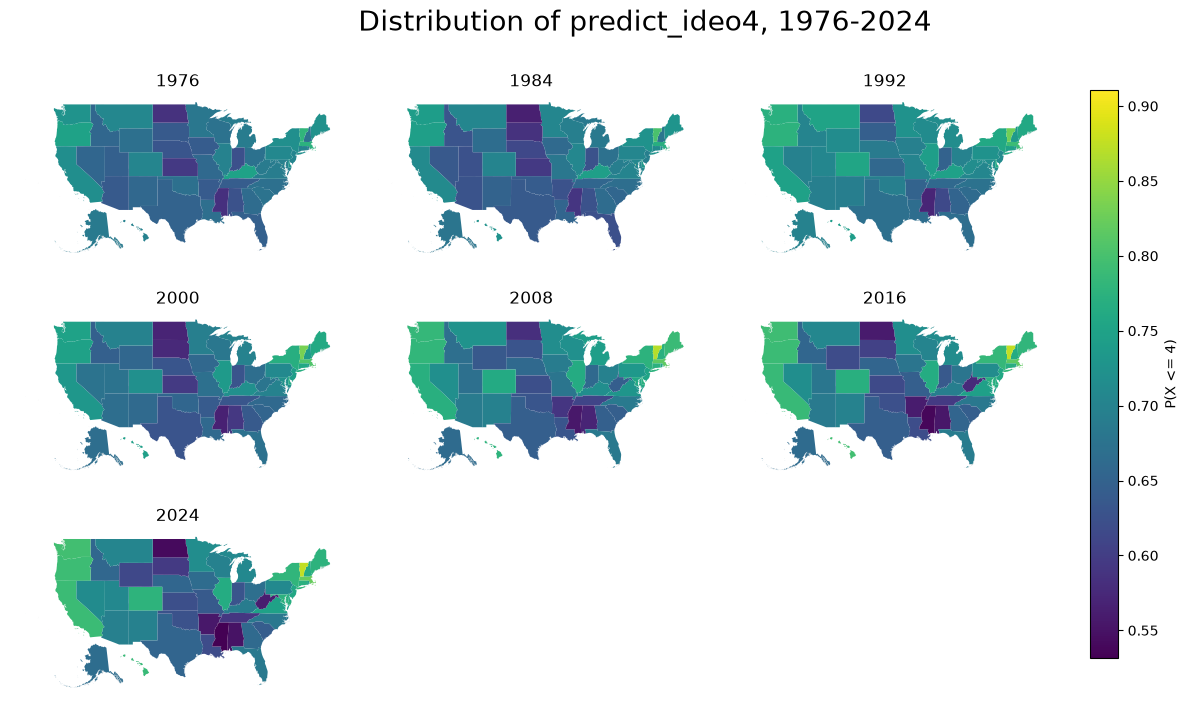

/var/folders/vh/xl1lkb0j3bbby54dm6r_rm640000gn/T/ipykernel_46167/948012956.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.825, 0.99])


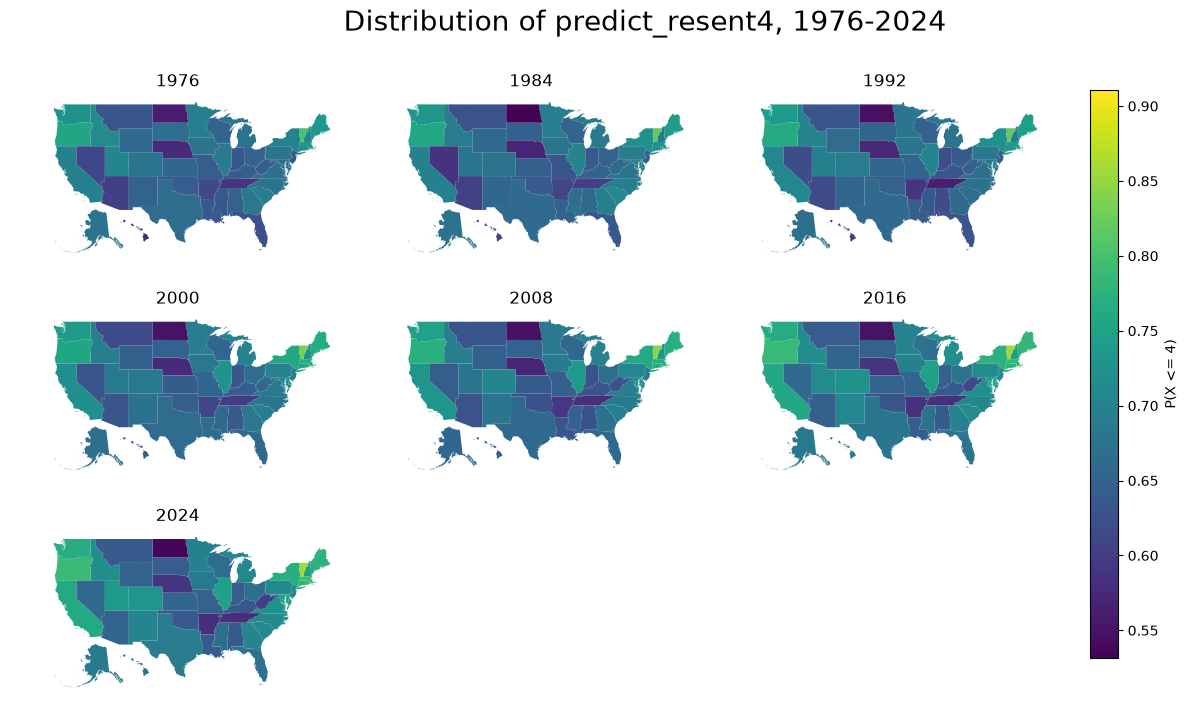

In [ ]:
"""Load the greater US shapefile data in the working directory under greater_us_shapefiles/ and 
create plots of the distribution of resentment and ideology across US states and time"""

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

states = gpd.read_file("raw_data/greater_us_state_shapefiles/us_states.shp")
states = states.rename(columns={"STUSPS": "state"})
states = states[["state", "geometry"]]

# Merge geometry with ideology estimates
plot_data = states.merge(state_ideology_time_series, on='state', how="right")
plot_data_subs = plot_data[ (plot_data['year'] - 2000) % 8 == 0 ] 
plot_data_subs = plot_data_subs[plot_data_subs['year'] >= 1972]
#plot_data[plot_data['year'] == 2024].plot("predict_resent4", legend=True)


def plot_variable(variable):
    years = sorted(plot_data_subs['year'].unique())
    ncols = 3
    nrows = int(np.ceil(len(years) / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(13, 2.5 * nrows)
    )
    axes = np.atleast_1d(axes).flatten()

    vmin = plot_data_subs[variable].min()
    vmax = plot_data_subs[variable].max()

    for ax, year in zip(axes, years):
        plot_data_subs.loc[
            plot_data_subs['year'] == year
        ].plot(
            column=variable,
            ax=ax,
            cmap='viridis',
            vmin=vmin,
            vmax=vmax,
            legend=False
        )
        ax.set_title(str(year))
        ax.set_axis_off()

    for ax in axes[len(years):]:
        ax.set_visible(False)

    cmap = 'viridis'
    norm = Normalize(
        vmin=plot_data_subs['predict_resent4'].min(),
        vmax=plot_data_subs['predict_resent4'].max()
    )
    
    plt.tight_layout()
    colorbar = fig.colorbar(
        ScalarMappable(norm=norm, cmap=cmap),
        ax=axes.tolist(),
        shrink=0.8,
        label='P(X <= 4)') 
    fig.suptitle(f'Distribution of {variable}, 1976-2024', size = 20)
    plt.tight_layout(rect=[0, 0, 0.825, 0.99])
    plt.show()     

plot_variable('predict_ideo4')
plot_variable('predict_resent4')


In [ ]:

#Use mean placements of all respondents of candidates so that we may represent candidate ideology as a single point
anes['vote_pres_bin'] = anes['vote_pres'].map({'Democrat': 0, 'Republican': 1})
vote_model = smf.logit(formula = 'vote_pres_bin ~ state + delta_dem_ideo + delta_gop_ideo + delta_dem_resent + delta_gop_resent', data=anes).fit()
#vote_model = smf.logit(formula = 'vote_pres_bin ~ delta_dem_ideo_indiv + delta_gop_ideo_indiv + delta_dem_resent_indiv + delta_gop_resent_indiv', data=anes).fit()

vote_model.summary()

#anes['predicted'] = vote_model.fittedvalues

Optimization terminated successfully.
         Current function value: 0.589178
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:          vote_pres_bin   No. Observations:                20404
Model:                          Logit   Df Residuals:                    20349
Method:                           MLE   Df Model:                           54
Date:                Sun, 30 Aug 2026   Pseudo R-squ.:                  0.1454
Time:                        22:42:32   Log-Likelihood:                -12022.
converged:                       True   LL-Null:                       -14066.
Covariance Type:            nonrobust   LLR p-value:                     0.000
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            1.6904      0.842      2.007      0.045       0.040       3.341
state[T.AL]         -1.1091      0.849     -1.306      0.192      -2.774       0.555
state[T.AR]         -0.9016      0.855     -1.055      0.292      -2.577       0.774
state[T.AZ]         -1.2487      0.848     -1.472      0.141      -2.911       0.414
state[T.CA]         -1.7009      0.843     -2.019      0.044      -3.352      -0.050
state[T.CO]         -1.5185      0.848     -1.791      0.073      -3.180       0.143
state[T.CT]         -1.4763      0.851     -1.736      0.083      -3.143       0.191
state[T.DC]         -4.4718      1.031     -4.337      0.000      -6.493      -2.451
state[T.DE]         -2.1160      0.934     -2.264      0.024      -3.947      -0.284
state[T.FL]         -1.1186      0.844     -1.326      0.185      -2.772       0.535
state[T.GA]         -1.3113      0.846     -1.549      0.121      -2.970       0.348
state[T.HI]         -1.6571      0.938     -1.766      0.077      -3.497       0.182
state[T.IA]         -0.8572      0.851     -1.007      0.314      -2.526       0.811
state[T.ID]         -1.4362      0.870     -1.650      0.099      -3.142       0.270
state[T.IL]         -1.6430      0.845     -1.945      0.052      -3.299       0.013
state[T.IN]         -0.9756      0.848     -1.151      0.250      -2.637       0.686
state[T.KS]         -0.9695      0.854     -1.135      0.256      -2.643       0.704
state[T.KY]         -0.9722      0.855     -1.137      0.256      -2.648       0.704
state[T.LA]         -1.3242      0.851     -1.556      0.120      -2.992       0.343
state[T.MA]         -2.0185      0.847     -2.384      0.017      -3.678      -0.359
state[T.MD]         -1.7013      0.848     -2.006      0.045      -3.363      -0.039
state[T.ME]         -1.1377      0.880     -1.293      0.196      -2.862       0.587
state[T.MI]         -1.2724      0.845     -1.507      0.132      -2.928       0.383
state[T.MN]         -1.5894      0.847     -1.877      0.061      -3.249       0.070
state[T.MO]         -1.0975      0.849     -1.292      0.196      -2.762       0.567
state[T.MS]         -1.2665      0.858     -1.476      0.140      -2.948       0.415
state[T.MT]         -1.3795      0.902     -1.529      0.126      -3.148       0.389
state[T.NC]         -1.5935      0.846     -1.884      0.059      -3.251       0.064
state[T.ND]         -0.4528      0.903     -0.502      0.616      -2.222       1.316
state[T.NE]         -1.0644      0.866     -1.230      0.219      -2.761       0.632
state[T.NH]         -1.6023      0.863     -1.856      0.063      -3.295       0.090
state[T.NJ]         -1.2526      0.846     -1.480      0.139      -2.911       0.406
state[T.NM]         -1.4180      0.867     -1.636      0.102      -3.117       0.281
state[T.NV]         -1.6134      0.864     -1.867      0.062      -3.308       0.081
state[T.NY]         -1.6944      0.844     -2.008      0.045      -3.348      -0.040
state[T.OH]

In [ ]:


def rake(sample, target_marginal_probs, rake_keys):
    sample_marginal_probs = {}
    #creates dict of dataframes, each containing marginal probabilities of categories for one categorical variable
    scalars = dict()
    max_iter = 10
    i = 0
    converge = dict(zip(rake_keys, [False] * len(rake_keys)))
    converge_thresh = 0.9975
    corr = 0

    #convert sample categories to target categories
    sample_convert = sample.copy() #pd.DataFrame(sample[rake_keys + ['weight1']])
    for key in mapping.keys():#covert all columns that have mappings to census variables
        anes_to_census = mapping[key] 
        sample_convert[key] = sample[key].apply(lambda x: anes_to_census[x])

    while i < max_iter and not all(converge.values()):
        prob_table = pd.DataFrame()
        for key in rake_keys:
            #need to update sample_marginal_probs after each iteration
            sample_marginal_probs[key] = sample_convert.groupby(key)['weight1'].agg(pd.Series.sum) / sample_convert['weight1'].sum() 
            target = pd.Series(target_marginal_probs[key].loc[0])
            joined = pd.concat([target, sample_marginal_probs[key]], axis = 'columns').fillna(1)
            scalars_new = dict(joined.iloc[:,0] / joined.iloc[:,1])

            #create dataframe to compute correlation between sample and target marginals
            sample = pd.Series(sample_marginal_probs[key]) 
            target = pd.Series(target_marginal_probs[key].loc[0])
            prob_table = pd.concat([prob_table, pd.concat([sample, target], axis = 'columns')], axis = 'index')
            
            if i > 0 and corr > converge_thresh:
                converge[key] = True
            else:
                scalars[key] = scalars_new

            #convert anes category to census category and get corresponding scalar
            scalar_vect = sample_convert[key].apply(lambda x: scalars_new[x])
            sample_convert['weight1'] = sample_convert['weight1'] * scalar_vect

        corr = np.corrcoef(prob_table.iloc[:,0].fillna(0), prob_table.iloc[:,1].fillna(0))[1,0]
        i+=1

    if PRINT_RAKING:
        print(f'Converged after {i} iterations. \n' + 
            f'Marginal probability correlation: {corr :<1.4f}')

    return sample_convert


def simulate_election(election, model_fundamentals_dict):
    sim_df = election['df']
    for party in election['parties']:
        #Below, we predict vote shares for parties outside the dataset by using the existing fundamentals model for party x
        #and creating a copy of the election df and modifying colnames so they are prefixed with party x (i.e. dem)
        #Relevant smf source code (model.py): def predict(self, exog)
        # def _transform_predict_exog(self, exog, transform=True): model.py
        # throwing an error as below allows prints stacktrace where smf routines are
        #sim_df[f'{party}_pred_vote_prob'] = model_fundamentals_dict[party].predict(sim_df.transpose())

        #TODO: redesign the prediction of third party vote shares so that you do not need to rename columns
        #TODO: eliminate the ugly capitalization syntax in the ELECTION dictionary
        if party in ['dem', 'gop']:
            sim_df[f'{party}_pred_vote_prob'] = model_fundamentals_dict[party].predict(sim_df)
        else:
            temp_df = sim_df.copy()
            party_vars = list(election['mult_in_dir_of_incumbency'].copy())
            party_vars.append('poll')
            party_vars.append('diff')
            new_names = []
            if 'dem' in DEFAULT_REGR:   
                new_names = [f'dem_{x}' for x in party_vars]
            elif 'gop' in DEFAULT_REGR:
                new_names = [f'gop_{x}' for x in party_vars]
            else:
                print('Error: Default regression model not identified.')

            names = [f'{party}_{x}' for x in party_vars]
            temp_df = temp_df.drop(columns = new_names)#drop existing cols prefixed with dem/gop and insert new ones
            temp_df = temp_df.rename(columns = dict(zip(names, new_names)))
            
            sim_df[f'{party}_pred_vote_prob'] = model_fundamentals_dict[party].predict(temp_df)

    if MULT_BY_POLLS:
        sim_df = mult_by_polls(election)

    if CONSTRAIN_VOTE_PROB:
        party_keys = [f'{party}_pred_vote_prob' for party in election['parties']]
        sum_probs = sim_df[party_keys].sum(axis = 'columns')
        constrained = sim_df[party_keys].apply(lambda x: x / sum_probs, axis = 'index') 
        sim_df = sim_df.drop(party_keys, axis = 'columns')
        sim_df = sim_df.join(constrained)

    return sim_df


def get_vote_shares(election, df = None):
    if type(df) == pd.DataFrame:
        pass
    else:
        df = election['df']

    parties = election['parties']
    total = 0
    shares = {}
    for party in parties:
        shares[f'{party}_share'] = np.sum(df[f'{party}_pred_vote_prob']*df['weight1']) / np.sum(df['weight1'])
        total += shares[f'{party}_share']    #normalize vote shares -- may result in increased error

    return shares




In [ ]:
rake(target_marginal_probs=[state_ideology_time_series[:,1:?]], rake_keys=['ideo_0','ideo_1','ideo_2'...'resent_0','resent_1'...])